In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized import TVqRegularized
from bimpcc.models.tvq_denoising import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()

In [4]:
scale = 4

In [5]:
dataset = get_dataset("cameraman",scale=scale)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(3.5), np.float64(3.5), np.float64(-0.5))

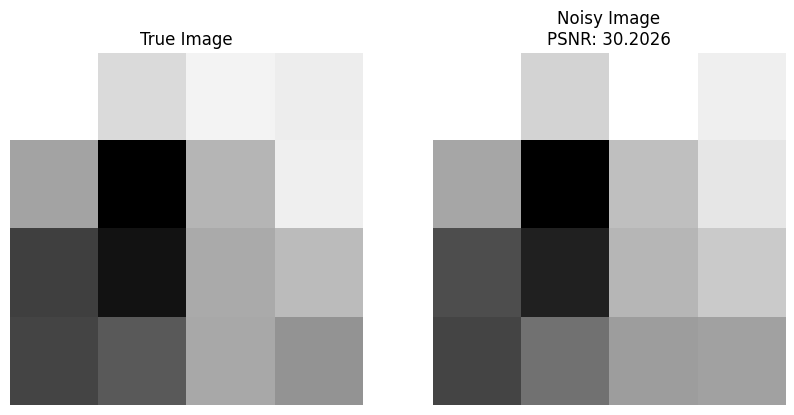

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=0.99)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:      290
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       41
                     variables with only lower bounds:       17
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       40
Total number of inequality c

In [9]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

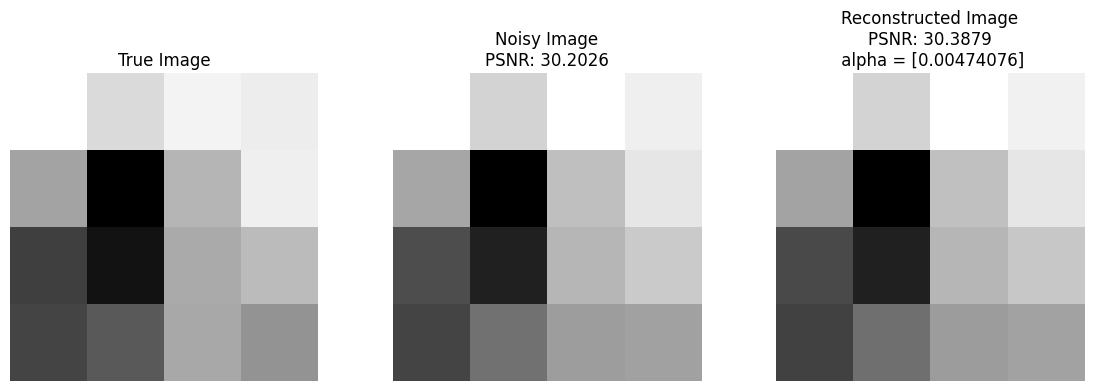

In [10]:
u_scaled = u.reshape((scale,scale))
plot_experiment(true,noisy,u_scaled,alpha)

In [11]:
Kx, Ky, K = generate_2D_gradient_matrices(scale)

In [ ]:
mm = q.flatten().size # mm=2m...q\in R^2m
m = mm // 2 

Ku = K @ u.flatten() # u\in R^n
V = Ku.reshape(2, -1).T
normKu = np.apply_along_axis(np.linalg.norm, axis=1, arr=V)
Q = q.reshape(2,-1).T
normQ = np.apply_along_axis(np.linalg.norm, axis=1, arr=Q)
r0 = normKu
delta0 = normQ

(12, 2)


In [13]:
Kxu = Ku[:m]  # Primeras m componentes de Ku = [Kxu_{mxn}  Kyu_{mxn}]^T
Kyu = Ku[m:]  # Últimas m componentes
qx = q[:m]  # Primeras m componentes
qy = q[m:]  # Últimas m componentes
epsilon = 1e-10  

# Calculamos theta:
theta0 = np.zeros(m)  # Inicializamos theta0

# Caso 1: r_i ≠ 0
mask_r_nonzero = r0 > epsilon
theta0[mask_r_nonzero] = np.arccos(Kxu[mask_r_nonzero] / r0[mask_r_nonzero])
theta0[mask_r_nonzero & (Kyu < 0)] *= -1  # Si Ky^i u < 0, multiplico por -1

# Caso 2: r_i = 0 y delta_i ≠ 0
mask_r_zero_delta_nonzero = (r0 <= epsilon) & (delta0 > epsilon)
theta0[mask_r_zero_delta_nonzero] = np.arccos(qx[mask_r_zero_delta_nonzero] / delta0[mask_r_zero_delta_nonzero])
theta0[mask_r_zero_delta_nonzero & (qy < 0)] *= -1  # Si qy^i < 0, multiplico por -1

# Caso 3: r_i = 0 y delta_i = 0 (theta0 indefinido)
mask_r_zero_delta_zero = (r0 <= epsilon) & (delta0 <= epsilon)
theta0[mask_r_zero_delta_zero] = 0 # asignamos 0

In [14]:
x0_mpcc = np.concatenate((u.flatten(),q.flatten(),r0,delta0,theta0,alpha))
# print(x0_mpcc)

In [21]:
q_param = 0.99
mpcc_model = TVDenoisingMPCC(true, noisy, x0=x0_mpcc, epsilon=1e-3, q_param = q_param)

In [16]:
res_mpcc,x_opt_mpcc,fun_opt_mpcc, history = mpcc_model.solve(max_iter=100,tol=1e-4,print_level=5,verbose=True)

Iter   Termination_status            Objective      MPCC_compl               t

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:      326
Number of nonzeros in inequality constraint Jacobian.:       60
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       77
                     variables with only lower bounds:       41
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       64
Total number of inequality constraints...............:       24
        inequality constraints with only lower bounds:       24
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  7.3164438e-03 6.24e-03 7.65e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:123: RuntimeWarning: invalid value encountered in power
  - beta * q_param / normKu * (normKu + (q_param - 1) / gamma) ** (q_param - 1),
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:198: RuntimeWarning: invalid value encountered in power
  (1 / (normKu**3)) * (normKu + (q_param - 1) / gamma) ** (q_param - 1)
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:200: RuntimeWarning: invalid value encountered in power
  * (normKu + (q_param - 1) / gamma) ** (q_param - 2)
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:203: RuntimeWarning: invalid value encountered in power
  e = (beta * delta_gamma) / normKu - (beta * q_param / normKu) * (
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_tvq.py:211: RuntimeWarning: invalid value encountered in power
  delta_gamma - q_param * (normKu + (q_param - 1) / gamma) ** (q_param - 1)

  36  4.7618776e-03 2.60e-05 2.35e-03  -6.5 1.93e-02    -  1.00e+00 9.98e-01h  1
  37  4.7586216e-03 3.62e-05 1.90e-03  -7.6 4.40e-02    -  1.00e+00 1.00e+00h  1
  38  4.7877487e-03 2.20e-05 8.99e-03  -8.2 2.35e-01    -  9.98e-01 1.00e+00H  1
  39  5.2410607e-03 7.45e-06 1.64e-02  -8.3 4.36e-01    -  1.00e+00 1.00e+00H  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  40  5.2325780e-03 1.27e-05 1.62e-02  -8.3 3.19e-01    -  3.84e-02 7.81e-03h  8
  41  5.2319188e-03 1.35e-05 1.58e-02  -8.3 4.91e-01    -  9.99e-02 4.04e-04h 10
  42  5.2315868e-03 1.38e-05 1.58e-02  -8.3 3.48e-01    -  1.23e-01 2.44e-04h 13
  43  5.2314695e-03 1.40e-05 1.58e-02  -8.3 7.02e-01    -  5.88e-02 5.98e-05h 15
  44  6.5502260e-03 1.16e-06 4.54e-02  -8.3 1.26e-01    -  3.36e-01 1.00e+00H  1
  45  4.7311444e-03 2.86e-03 6.56e-03  -6.2 1.90e-01    -  8.13e-01 1.00e+00f  1
  46  4.7441842e-03 2.41e-04 3.13e-03  -5.9 1.24e-02    -  1.00e+00 1.00e+00h  1
  47  4.7342077e-03 1.03e-04

0                 0  0.004725309645511084    1.3273248152067674                 1.0

...

Constraint violation....:   3.5023234529543701e-10    3.5023234529543701e-10
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   1.4867144947757349e-11    1.4867144947757349e-11
Overall NLP error.......:   7.1168920272569771e-08    7.1168920272569771e-08


Number of objective function evaluations             = 13
Number of objective gradient evaluations             = 13
Number of equality constraint evaluations            = 13
Number of inequality constraint evaluations          = 13
Number of equality constraint Jacobian evaluations   = 13
Number of inequality constraint Jacobian evaluations = 13
Number of Lagrangian Hessian evaluations             = 0
Total seconds in IPOPT                               = 0.218

EXIT: Optimal Solution Found.


Intermediate result:  message: b'Algorithm terminated successfully at a locally optimal point, satisfying the 
convergence tolerances (can be specified by options).'
 success: True
  status: 0
     fun: 0.007307422492061198
       x: [ 9.937e-01  8.571e-01 ... -1.429e+00  4.758e-03]
     nit: 12
    info:     status: 0
                   x: [ 9.937e-01  8.571e-01 ... -1.429e+00  4.758e-03]
                   g: [-4.910e-09  2.234e-05 ... -7.665e-14 -9.549e-14]
             obj_val: 0.007307422492061198
              mult_g: [-2.921e-03 -4.400e-07 ... -6.633e-02  2.224e-04]
            mult_x_L: [ 1.006e-11  1.167e-11 ...  0.000e+00  2.108e-09]
            mult_x_U: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
          status_msg: b'Algorithm terminated successfully at a locally optimal point, satisfying the convergence 
tolerances (can be specified by options).'
    nfev: 13
    njev: 14

Intermediate fn: 0.007307422492061198

complementarity: 0.00018071502101142689

* (STOPPED) Iteration 18: Solving the NLP problem for t = 1e-05 with complementarity: 0.00018071502101142689

In [17]:
u_mpcc, q_mpcc, r_mpcc, delta_mpcc, theta_mpcc, alpha_mpcc = mpcc_model.objective_func.parse_vars(x_opt_mpcc)

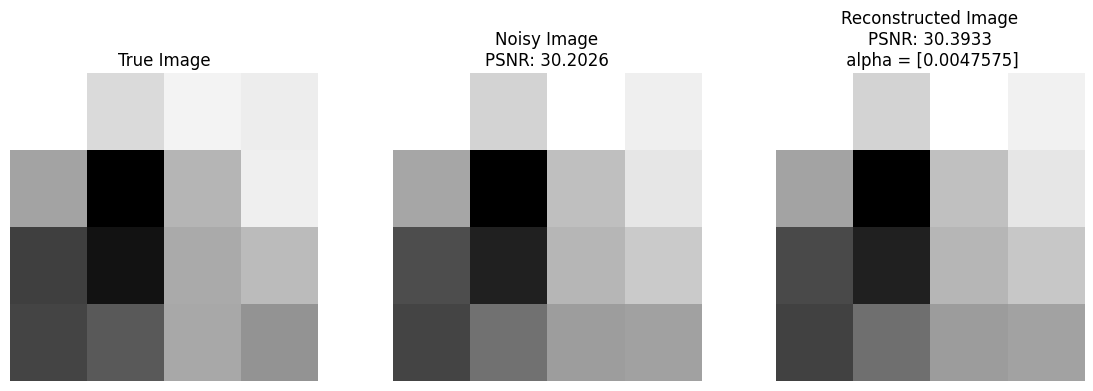

In [18]:
u_mpcc_scaled = u_mpcc.reshape((scale,scale))
plot_experiment(true,noisy,u_mpcc_scaled,alpha_mpcc)

In [25]:
def history_to_latex(
    history,
    experiment_name="tabla_mpcc",
):
    def fmt(x):
        if x is None:
            return "-"
        if isinstance(x, int):
            return f"{x}"
        x = float(x)
        if x != 0 and (abs(x) < 1e-3 or abs(x) >= 1e4):
            base, exp = f"{x:.3e}".split("e")
            return f"{base}\\times 10^{{{int(exp)}}}"
        return f"{x:.6f}"

    lines = []
    lines.append("\\begin{tabular}{c c c c c c}")
    lines.append("\\toprule")
    lines.append("Iter & Compl & NLP iter & Fun Obj & $t$ & $\\alpha$ \\\\")
    lines.append("\\midrule")

    for row in history:
        lines.append(
            f"{fmt(row['k'])} & "
            f"{fmt(row['comp'])} & "
            f"{fmt(row['nlp_iter'])} & "
            f"{fmt(row['obj'])} & "
            f"{fmt(row['t'])} & "
            f"{fmt(row['alpha'])} \\\\"
        )

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")

    latex_table = "\n".join(lines)

    # -----------------------------
    # Crear carpeta y guardar
    # -----------------------------
    results_dir = "results_table"
    os.makedirs(results_dir, exist_ok=True)

    table_path = os.path.join(results_dir, f"{experiment_name}.tex")
    with open(table_path, "w", encoding="utf-8") as f:
        f.write(latex_table)

    print(f"Tabla LaTeX guardada en: {table_path}")

    return 

In [26]:
history_to_latex(
    history,
    experiment_name=(f"tabla_mpcc_{q_param}"),
)

Tabla LaTeX guardada en: results_table/tabla_mpcc_0.99.tex
